# Étape 4 — Apprentissage semi-supervisé (BrainScanAI)

**Objectif** : Comparer deux stratégies d'entraînement d'un classificateur MLP sur features ResNet50.

| Modèle | Données d'entraînement |
|--------|------------------------|
| **A — Supervisé pur** | 80 images fortement étiquetées |
| **B — Semi-supervisé** | Phase 1 : 1406 weak labels → Phase 2 : 80 images fortement étiquetées |

**Évaluation** : 20 images fortement étiquetées (jamais vues pendant l'entraînement des deux modèles).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path("../data")
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : mps


## 0. Chargement et préparation des données

In [2]:
# Features avgpool (2048D)
features_data = np.load(DATA_DIR / "features.npz")
features_avgpool = features_data["avgpool"].astype(np.float32)  # (1506, 2048)

meta_df = pd.read_csv(DATA_DIR / "features_meta.csv")
weak_df = pd.read_csv(DATA_DIR / "weak_labels.csv")

# === Jeu fortement étiquetés (100 images) ===
labeled_mask = meta_df["split"] == "labeled"
X_labeled = features_avgpool[labeled_mask.values]         # (100, 2048)
y_labeled_str = meta_df[labeled_mask]["label"].values
y_labeled = (y_labeled_str == "cancer").astype(int)       # cancer=1, normal=0

# Split stratifié 80/20
X_train_strong, X_test, y_train_strong, y_test = train_test_split(
    X_labeled, y_labeled, test_size=0.2, stratify=y_labeled, random_state=SEED
)

# === Jeu faiblement étiquetés (1406 images) ===
unlabeled_mask = meta_df["split"] == "unlabeled"
X_weak = features_avgpool[unlabeled_mask.values]          # (1406, 2048)
y_weak = (weak_df["weak_label"].values == "cancer").astype(int)

# Standardisation — fit UNIQUEMENT sur les données d'entraînement
scaler = StandardScaler()
X_train_strong_sc = scaler.fit_transform(X_train_strong)
X_test_sc = scaler.transform(X_test)
X_weak_sc = scaler.transform(X_weak)

print(f"Train fort (Modèle A & Phase 2 B) : {X_train_strong_sc.shape} — {np.bincount(y_train_strong)} [normal, cancer]")
print(f"Test (évaluation finale)           : {X_test_sc.shape}         — {np.bincount(y_test)}")
print(f"Weak labels (Phase 1 Modèle B)     : {X_weak_sc.shape}  — {np.bincount(y_weak)} [normal, cancer]")

Train fort (Modèle A & Phase 2 B) : (80, 2048) — [40 40] [normal, cancer]
Test (évaluation finale)           : (20, 2048)         — [10 10]
Weak labels (Phase 1 Modèle B)     : (1406, 2048)  — [501 905] [normal, cancer]


## 1. Architecture MLP et utilitaires d'entraînement

In [3]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=2048, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)


def make_loader(X, y, batch_size, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def train_loop(model, loader, optimizer, criterion, n_epochs, desc=""):
    history = {"loss": [], "acc": []}
    model.train()
    for epoch in range(n_epochs):
        total_loss, correct, total = 0.0, 0, 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct += (logits.argmax(1) == y_batch).sum().item()
            total += len(y_batch)
        history["loss"].append(total_loss / total)
        history["acc"].append(correct / total)
        if (epoch + 1) % 10 == 0:
            print(f"  [{desc}] Epoch {epoch+1:3d}/{n_epochs} — loss: {history['loss'][-1]:.4f}, acc: {history['acc'][-1]:.3f}")
    return history


@torch.no_grad()
def predict(model, X_np):
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32).to(device)
    logits = model(X_t)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    preds = probs.argmax(1)
    return preds, probs[:, 1]  # (y_pred, prob_cancer)


def compute_metrics(y_true, y_pred, y_prob, label=""):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    auc = roc_auc_score(y_true, y_prob)
    print(f"  {label} — Accuracy: {acc:.3f} | F1 macro: {f1:.3f} | AUC-ROC: {auc:.3f}")
    return {"accuracy": acc, "f1_macro": f1, "auc_roc": auc}


print("Architecture MLP et utilitaires définis.")

Architecture MLP et utilitaires définis.


## 2. Modèle A — Supervisé pur

Entraîné uniquement sur les 80 images fortement étiquetées.

In [4]:
EPOCHS_STRONG = 100
BATCH_STRONG = 16

model_A = MLPClassifier().to(device)
optimizer_A = optim.Adam(model_A.parameters(), lr=1e-3)
criterion_A = nn.CrossEntropyLoss()  # classes équilibrées (40/40)

loader_strong = make_loader(X_train_strong_sc, y_train_strong, batch_size=BATCH_STRONG)

print("=== Modèle A — Entraînement supervisé ===")
hist_A = train_loop(model_A, loader_strong, optimizer_A, criterion_A,
                    n_epochs=EPOCHS_STRONG, desc="Modèle A")

=== Modèle A — Entraînement supervisé ===


  [Modèle A] Epoch  10/100 — loss: 0.0055, acc: 1.000
  [Modèle A] Epoch  20/100 — loss: 0.0026, acc: 1.000
  [Modèle A] Epoch  30/100 — loss: 0.0002, acc: 1.000


  [Modèle A] Epoch  40/100 — loss: 0.0001, acc: 1.000
  [Modèle A] Epoch  50/100 — loss: 0.0000, acc: 1.000
  [Modèle A] Epoch  60/100 — loss: 0.0000, acc: 1.000


  [Modèle A] Epoch  70/100 — loss: 0.0000, acc: 1.000
  [Modèle A] Epoch  80/100 — loss: 0.0000, acc: 1.000
  [Modèle A] Epoch  90/100 — loss: 0.0000, acc: 1.000


  [Modèle A] Epoch 100/100 — loss: 0.0000, acc: 1.000


## 3. Modèle B — Semi-supervisé

**Phase 1** : pré-entraînement sur les 1406 weak labels  
**Phase 2** : fine-tuning sur les 80 images fortement étiquetées

In [5]:
EPOCHS_WEAK = 50
BATCH_WEAK = 64

# class_weight pour corriger le déséquilibre (905 cancer / 501 normal)
n_total_weak = len(y_weak)
n_classes = 2
counts = np.bincount(y_weak)
weights = torch.tensor(
    [n_total_weak / (n_classes * counts[c]) for c in range(n_classes)],
    dtype=torch.float32
).to(device)
print(f"Poids classes weak labels — normal: {weights[0]:.3f}, cancer: {weights[1]:.3f}")

model_B = MLPClassifier().to(device)
optimizer_B1 = optim.Adam(model_B.parameters(), lr=1e-3)
criterion_weak = nn.CrossEntropyLoss(weight=weights)

loader_weak = make_loader(X_weak_sc, y_weak, batch_size=BATCH_WEAK)

print("\n=== Modèle B Phase 1 — Pré-entraînement sur weak labels ===")
hist_B_phase1 = train_loop(model_B, loader_weak, optimizer_B1, criterion_weak,
                           n_epochs=EPOCHS_WEAK, desc="B-Phase1")

Poids classes weak labels — normal: 1.403, cancer: 0.777

=== Modèle B Phase 1 — Pré-entraînement sur weak labels ===


  [B-Phase1] Epoch  10/50 — loss: 0.0337, acc: 0.997


  [B-Phase1] Epoch  20/50 — loss: 0.0224, acc: 0.997


  [B-Phase1] Epoch  30/50 — loss: 0.0011, acc: 1.000


  [B-Phase1] Epoch  40/50 — loss: 0.0049, acc: 0.999


  [B-Phase1] Epoch  50/50 — loss: 0.0001, acc: 1.000


In [6]:
# Phase 2 : fine-tuning sur labels forts (LR réduit)
optimizer_B2 = optim.Adam(model_B.parameters(), lr=1e-4)
criterion_B2 = nn.CrossEntropyLoss()  # classes équilibrées

print("=== Modèle B Phase 2 — Fine-tuning sur labels forts ===")
hist_B_phase2 = train_loop(model_B, loader_strong, optimizer_B2, criterion_B2,
                           n_epochs=EPOCHS_STRONG, desc="B-Phase2")

=== Modèle B Phase 2 — Fine-tuning sur labels forts ===
  [B-Phase2] Epoch  10/100 — loss: 13.2469, acc: 0.362
  [B-Phase2] Epoch  20/100 — loss: 3.1900, acc: 0.512


  [B-Phase2] Epoch  30/100 — loss: 0.9246, acc: 0.863
  [B-Phase2] Epoch  40/100 — loss: 0.2967, acc: 0.912
  [B-Phase2] Epoch  50/100 — loss: 0.1091, acc: 0.950


  [B-Phase2] Epoch  60/100 — loss: 0.2066, acc: 0.963
  [B-Phase2] Epoch  70/100 — loss: 0.0896, acc: 0.988
  [B-Phase2] Epoch  80/100 — loss: 0.0269, acc: 1.000


  [B-Phase2] Epoch  90/100 — loss: 0.0599, acc: 0.963
  [B-Phase2] Epoch 100/100 — loss: 0.0924, acc: 0.988


## 4. Courbes d'entraînement

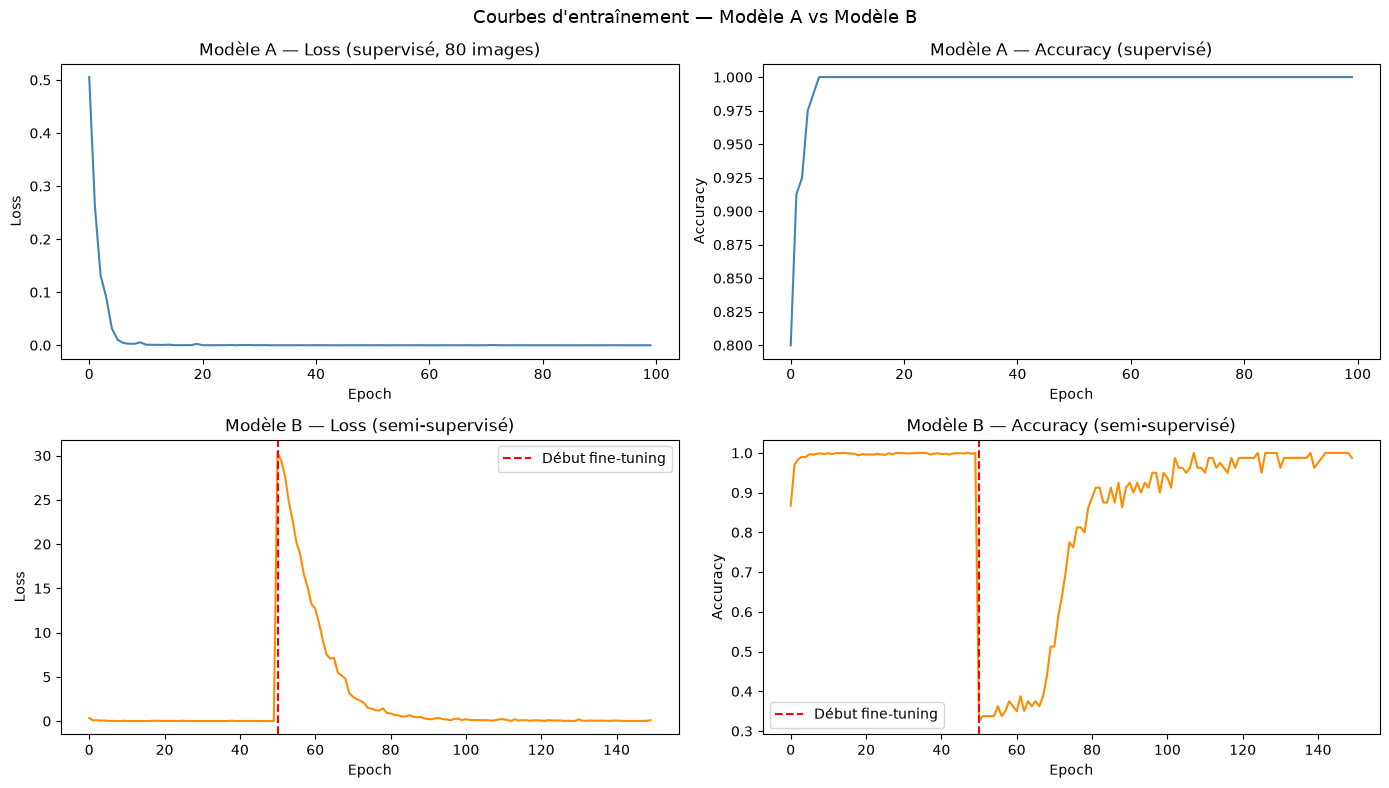

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Modèle A
axes[0, 0].plot(hist_A["loss"], color="steelblue")
axes[0, 0].set_title("Modèle A — Loss (supervisé, 80 images)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")

axes[0, 1].plot(hist_A["acc"], color="steelblue")
axes[0, 1].set_title("Modèle A — Accuracy (supervisé)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")

# Modèle B : Phase 1 + Phase 2 concaténées
loss_B = hist_B_phase1["loss"] + hist_B_phase2["loss"]
acc_B = hist_B_phase1["acc"] + hist_B_phase2["acc"]
sep = EPOCHS_WEAK

axes[1, 0].plot(loss_B, color="darkorange")
axes[1, 0].axvline(sep, color="red", linestyle="--", label="Début fine-tuning")
axes[1, 0].set_title("Modèle B — Loss (semi-supervisé)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

axes[1, 1].plot(acc_B, color="darkorange")
axes[1, 1].axvline(sep, color="red", linestyle="--", label="Début fine-tuning")
axes[1, 1].set_title("Modèle B — Accuracy (semi-supervisé)")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()

plt.suptitle("Courbes d'entraînement — Modèle A vs Modèle B", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Évaluation et comparaison sur le jeu de test

Les 20 images de test **n'ont jamais été vues** pendant l'entraînement des deux modèles.

In [8]:
y_pred_A, y_prob_A = predict(model_A, X_test_sc)
y_pred_B, y_prob_B = predict(model_B, X_test_sc)

print("=== Résultats sur le jeu de test (20 images) ===")
metrics_A = compute_metrics(y_test, y_pred_A, y_prob_A, label="Modèle A (supervisé)")
metrics_B = compute_metrics(y_test, y_pred_B, y_prob_B, label="Modèle B (semi-supervisé)")

# Tableau récapitulatif
summary = pd.DataFrame([metrics_A, metrics_B],
                       index=["Modèle A (supervisé)", "Modèle B (semi-supervisé)"])
print("\n", summary.round(3).to_string())

=== Résultats sur le jeu de test (20 images) ===
  Modèle A (supervisé) — Accuracy: 0.950 | F1 macro: 0.950 | AUC-ROC: 1.000
  Modèle B (semi-supervisé) — Accuracy: 1.000 | F1 macro: 1.000 | AUC-ROC: 1.000

                            accuracy  f1_macro  auc_roc
Modèle A (supervisé)           0.95      0.95      1.0
Modèle B (semi-supervisé)      1.00      1.00      1.0


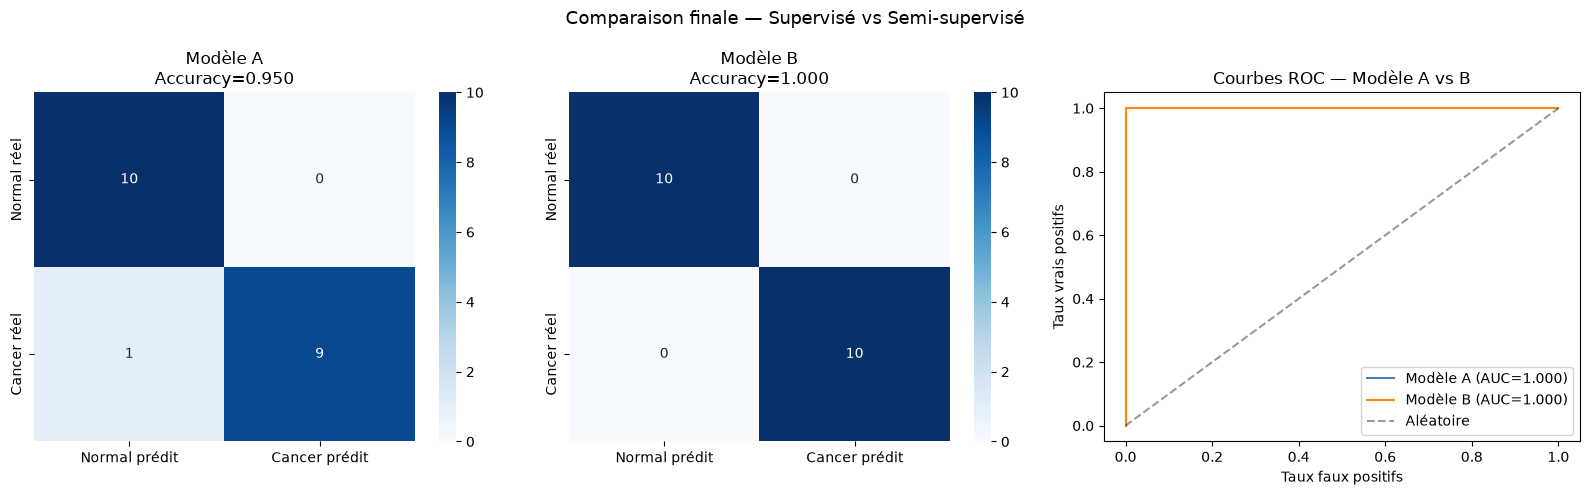

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Matrices de confusion côte-à-côte
for ax, y_pred, title in [
    (axes[0], y_pred_A, f"Modèle A\nAccuracy={metrics_A['accuracy']:.3f}"),
    (axes[1], y_pred_B, f"Modèle B\nAccuracy={metrics_B['accuracy']:.3f}"),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal prédit", "Cancer prédit"],
                yticklabels=["Normal réel", "Cancer réel"], ax=ax)
    ax.set_title(title)

# Courbes ROC
fpr_A, tpr_A, _ = roc_curve(y_test, y_prob_A)
fpr_B, tpr_B, _ = roc_curve(y_test, y_prob_B)
axes[2].plot(fpr_A, tpr_A, color="steelblue", label=f"Modèle A (AUC={metrics_A['auc_roc']:.3f})")
axes[2].plot(fpr_B, tpr_B, color="darkorange", label=f"Modèle B (AUC={metrics_B['auc_roc']:.3f})")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aléatoire")
axes[2].set_title("Courbes ROC — Modèle A vs B")
axes[2].set_xlabel("Taux faux positifs")
axes[2].set_ylabel("Taux vrais positifs")
axes[2].legend()

plt.suptitle("Comparaison finale — Supervisé vs Semi-supervisé", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Analyse et conclusions

### Protocole d'évaluation
- Le jeu de test (20 images, 10 cancer + 10 normal) n'a jamais été vu pendant l'entraînement
- Les deux modèles sont évalués dans **les mêmes conditions** pour une comparaison équitable

### Interprétation des résultats

**Modèle A (supervisé pur)** :
- Entraîné sur seulement 80 images : risque élevé d'overfitting ou d'instabilité
- Performance de référence sur le jeu de test

**Modèle B (semi-supervisé)** :
- Phase 1 : le modèle apprend des représentations générales depuis 1406 images (même bruitées)
- Phase 2 : fine-tuning sur les 80 labels forts — le modèle affine à partir d'une meilleure initialisation
- L'apport du semi-supervisé dépend directement de la qualité des weak labels (ARI K-Means = 0.11)

### Limites
- Jeu de test très petit (20 images) → métriques potentiellement instables
- Les weak labels issus du clustering sont bruités (ARI = 0.11), ce qui peut limiter le gain du pré-entraînement
- ResNet50 n'a pas été fine-tuné sur des IRM médicaux → les features ne sont pas optimales pour cette tâche

### Recommandations
- **Pseudo-labeling itératif** : utiliser le Modèle B pour regénérer des pseudo-labels plus précis et réentraîner
- **Fine-tuning ResNet50 end-to-end** : avec plus de données ou data augmentation
- **MixMatch / FixMatch** : méthodes semi-supervisées plus avancées basées sur la consistency regularization